# Генерация выборки

In [1628]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import math as mt
plt.style.use("ggplot")

# np.random.seed(44)


n = 25
sample = np.random.exponential(scale=1.0, size=n)
var_row = np.sort(sample)
print(sample)

[1.83275601 0.76017115 0.06354608 0.17790426 4.86068126 0.56213762
 1.59552646 0.60509285 0.69667287 0.16885286 0.70515204 3.48152291
 0.90472443 0.61625719 0.32133081 0.35678938 0.44552985 0.22493413
 0.41893372 5.14571066 0.38746896 0.26297451 4.04387122 0.82225406
 0.26200531]


In [1657]:
def F(x):
    if x < 0:
        return 0
    else:
        return 1 - np.exp(-x)
    
def p(x):
    if x < 0:
        return 0
    else:
        return np.exp(-x)

def Muk(x : np.ndarray, k : int):
    res = np.sum((x - np.mean(x))**k)/len(x)
    if res < 1e-14:
        res = 0
    return res

def distr_ordinal_stat(x, k):
    return p(x) * (mt.factorial(n)/(mt.factorial(k-1)*mt.factorial(n-k))) * ((1-F(x)) ** (n-k)) * (F(x) ** (k - 1)) 

def make_emric_distr_graph(selection: np.array):
    start_p = np.min(selection) - np.average(selection)
    stop_p = np.max(selection) + np.average(selection)
    
    sorted_sel = np.sort(selection)
    uniq = np.unique(sorted_sel)
    print(uniq[0])
    f_vals = np.array([empiric(x, selection) for x in uniq])
    f_vals[-1] = 1.0 
    
    plt.figure(figsize=(10, 6))
    
    plt.hlines(0, start_p, uniq[0], colors='#333333', linewidth=2)
    for i in range(len(uniq)-1):
        plt.hlines(f_vals[i], uniq[i], uniq[i+1], colors='#333333', linewidth=2)
    plt.hlines(1, uniq[-1], stop_p, colors='#333333', linewidth=2)
    
    for i, x in enumerate(uniq):
        y_bottom = 0 if i == 0 else f_vals[i-1]
        plt.plot([x, x], [y_bottom, f_vals[i]], ':', color='#333333', linewidth=1.5)
    
    for i in range(len(uniq)):
        if i == 0:
            plt.plot(uniq[i], f_vals[i], 'o', markerfacecolor='#ff9900', markeredgecolor='#ff9900', markersize=3)
        plt.plot(uniq[i], f_vals[i], 'o', markerfacecolor='none', markeredgecolor='#ff9900', markersize=6)
    
    margin = (stop_p - start_p) * 0.1
    plt.xlim(start_p - margin, stop_p + margin)
    
    plt.xlabel('x')
    plt.ylabel('F(x)')
    plt.title('Эмпирическая функция распределения')
    plt.grid(True, linestyle='--', alpha=0.5)


def empiric(x: float, selection: np.array):
    return len(selection[selection < x])/len(selection)


# а) Мода, медиана, размах, коэффициент ассиметрии

In [1630]:
mode = stats.mode(sample)[0] if stats.mode(sample)[1] != 1 else "В массиве все элементы разные"

print("Мода: ", mode)
print("Размах: ", np.max(sample) - np.min(sample))
print("Медиана: ", np.median(sample))
print("Коэффициент ассиметрии: ", Muk(sample, 3)/(Muk(sample,2)**1.5))

Мода:  В массиве все элементы разные
Размах:  5.082164584334307
Медиана:  0.6050928529988804
Коэффициент ассиметрии:  1.7192843430435942


# б) Эмпирическая функция распределения, гистограмма и boxplot

0.06354607617100684


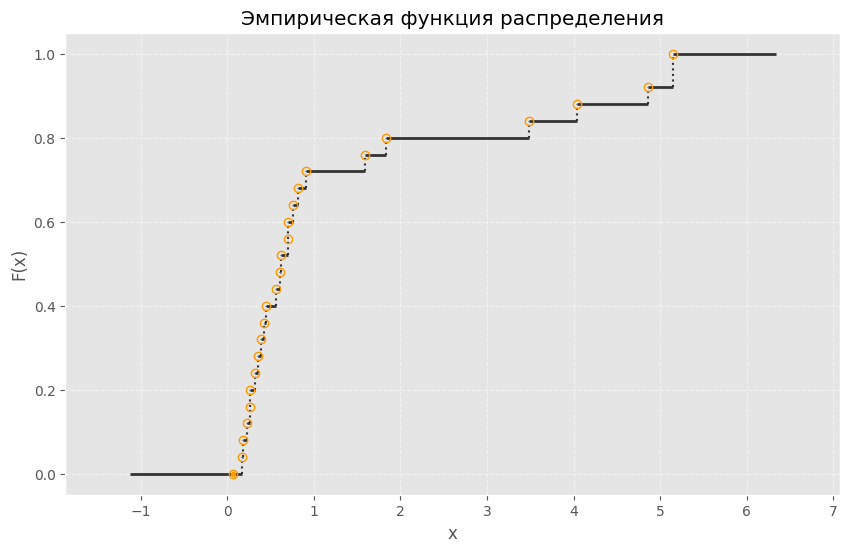

In [1658]:

make_emric_distr_graph(sample)

5 4.643856189774724


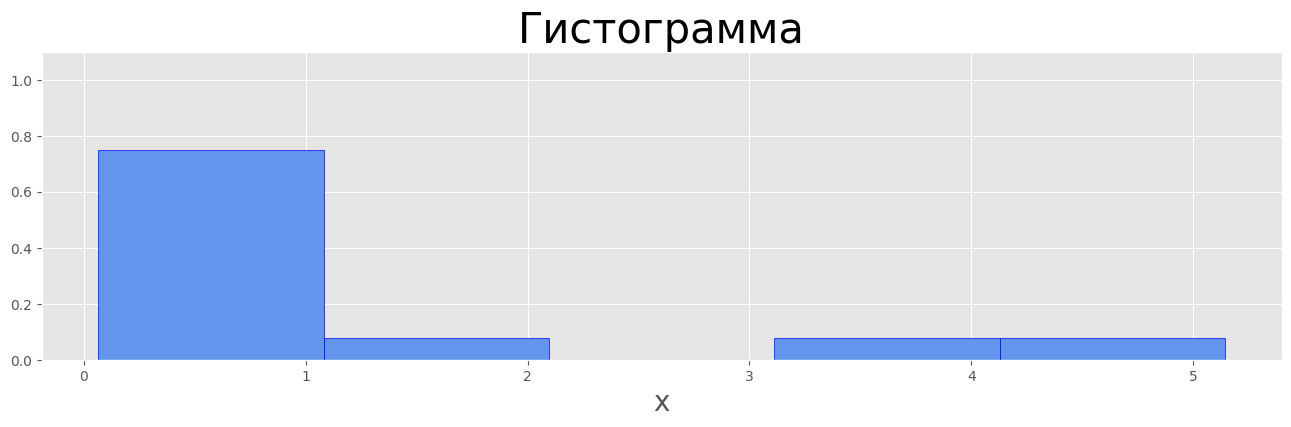

In [1632]:
figure, axis = plt.subplots(figsize=(16, 4))

k = int(np.floor(1 + np.log2(n)))
print(k, np.log2(n))
axis.hist(sample, bins=k, density=True, color="cornflowerblue", edgecolor="blue")
axis.set_ylim(top=1.1)
axis.set_title("Гистограмма",  fontsize=30)
axis.set_xlabel("x", fontsize=20)
axis.set_ylabel("", fontsize=20)
plt.show()

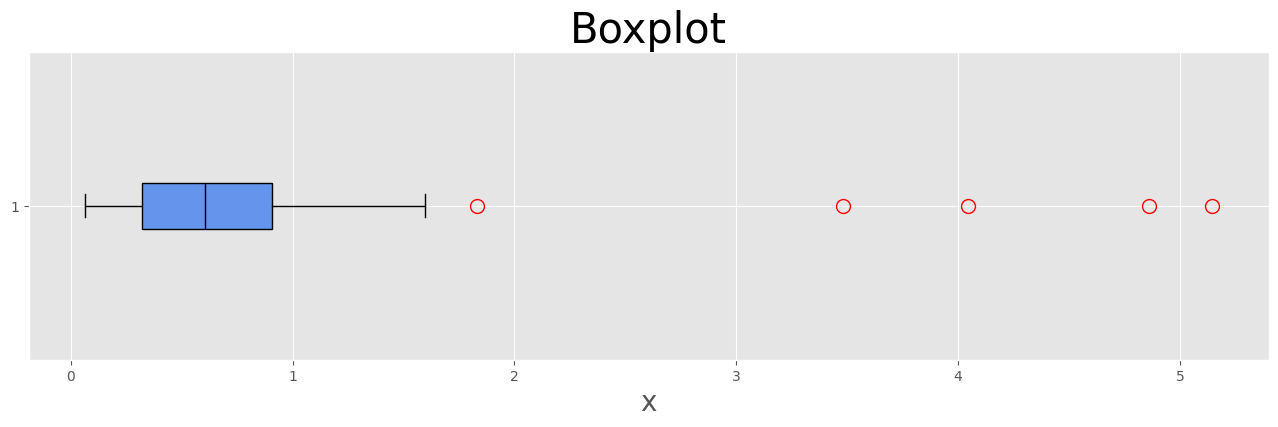

In [1644]:
figure, axis = plt.subplots(figsize=(16, 4))

axis.boxplot(
    sample,
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="cornflowerblue"),
    medianprops=dict(color="black"),
    flierprops =dict(markeredgecolor="red", markersize=10),
    # showfliers = False
)
axis.set_title("Boxplot",  fontsize=30)
axis.set_xlabel("x", fontsize=20)
plt.show()

#  с) Сравнить оценку плотности среднего арифметического элементов выборки, полученную с помощью ЦПТ, с бутстраповской оценкой этой плотности

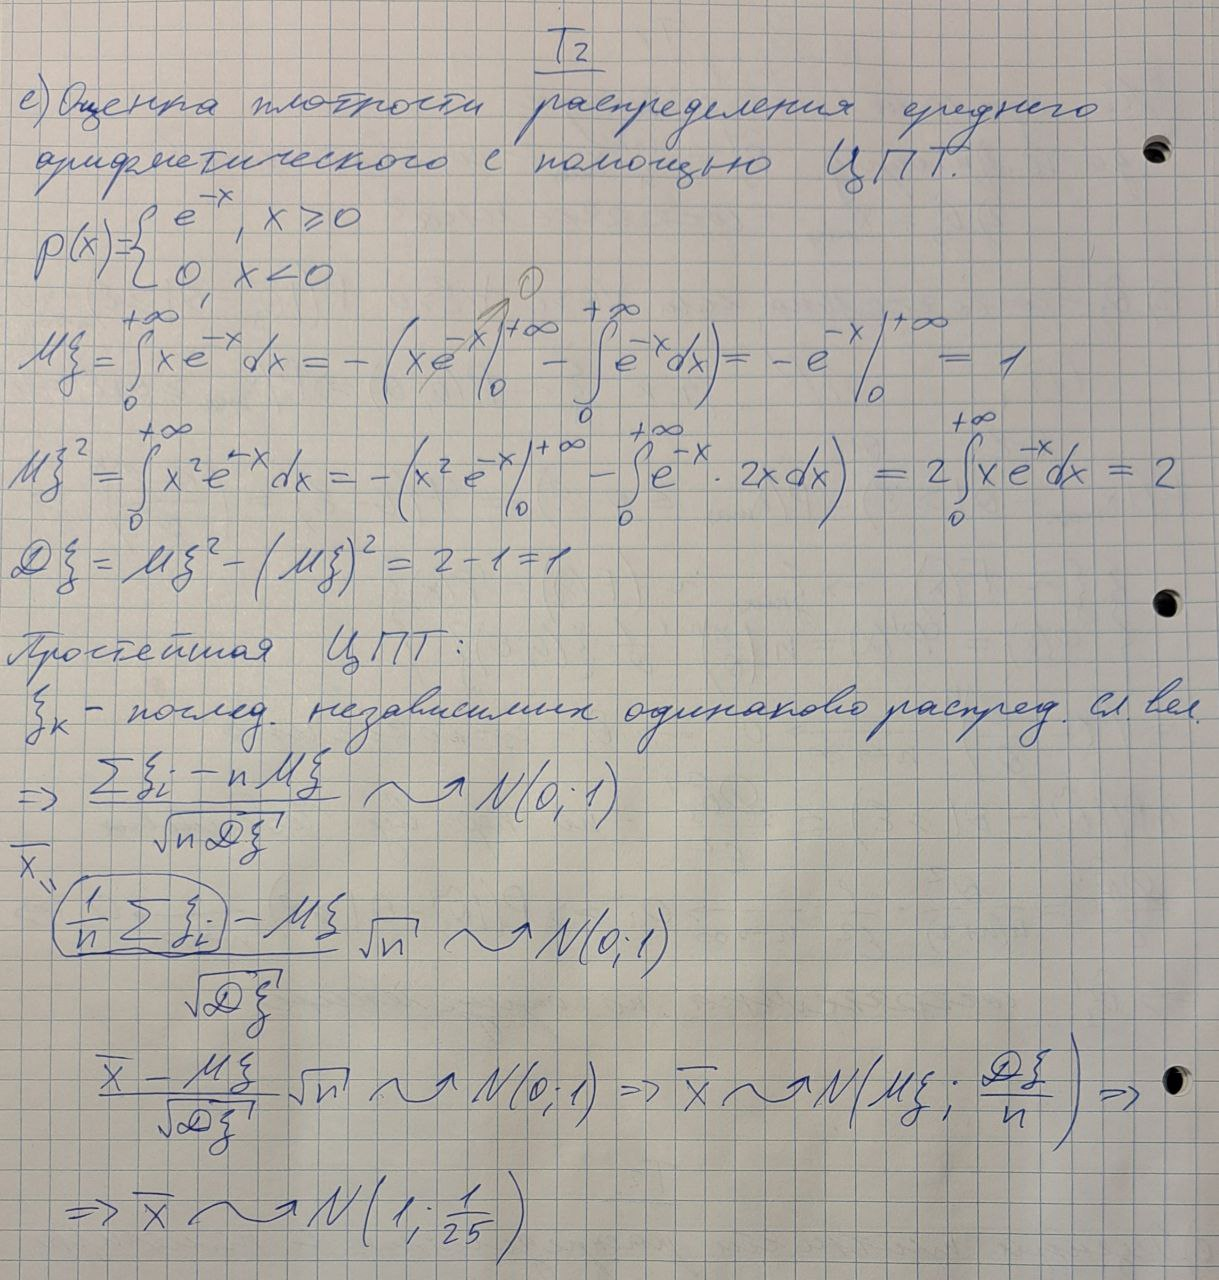

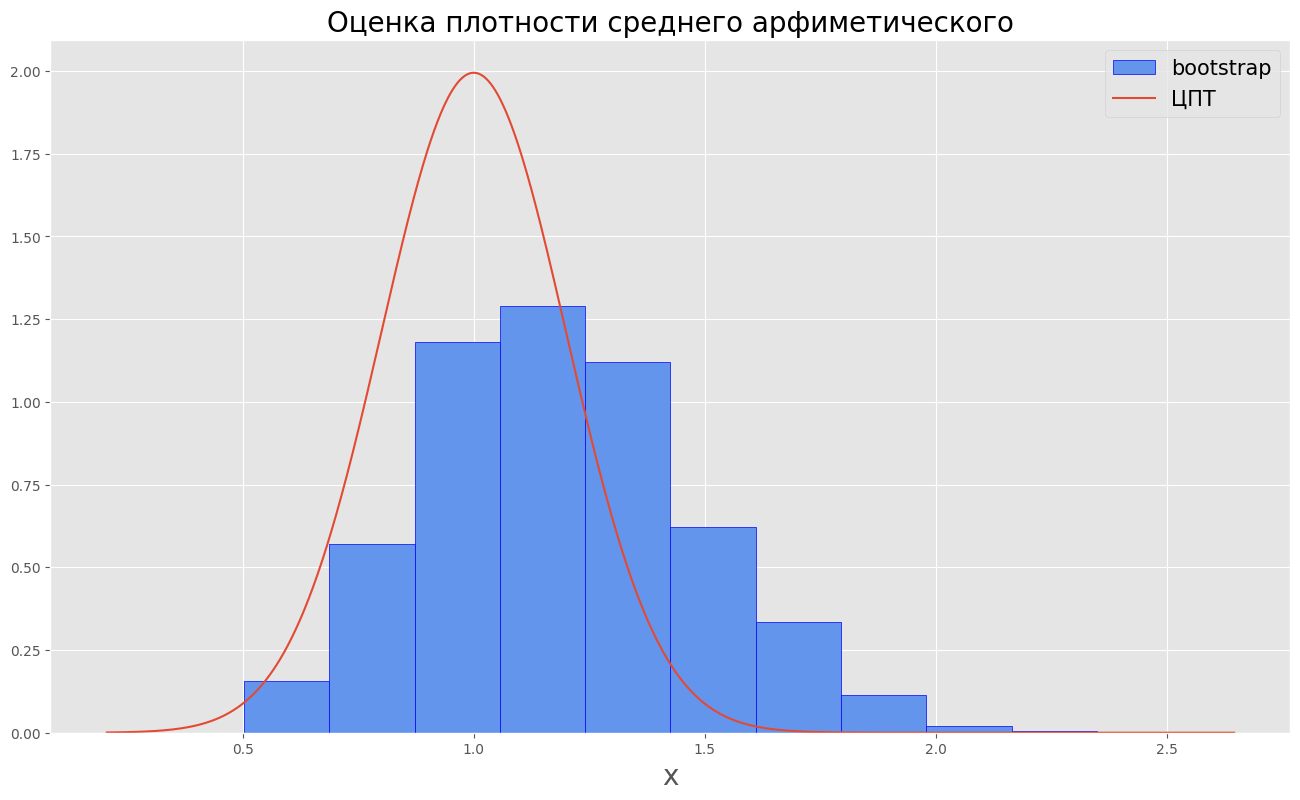

In [1634]:
N = 1000
K = int(1+np.log2(N))

def normal_distrib(x, m, sigma2):
   return  1/(np.sqrt(2*np.pi*sigma2))*np.exp(-(x-m)**2/(2*sigma2))

bt_mean = (stats.bootstrap((sample,), np.mean, n_resamples=N)).bootstrap_distribution
x = np.linspace(np.min(bt_mean) - np.mean(bt_mean)/4 , np.max(bt_mean) + np.mean(bt_mean)/4, 1000)
norm = normal_distrib(x, 1, 1/25)
figure, axis = plt.subplots(figsize=(16,9))
axis.hist(bt_mean, bins=K, density=True, color="cornflowerblue", edgecolor="blue", label="bootstrap")
axis.plot(x, norm, label="ЦПТ")
axis.set_xlabel("x", fontsize=20)
axis.set_title("Оценка плотности среднего арфиметического", fontsize=20)
axis.legend(fontsize=15)
plt.show()

# d) Найти бутстраповскую оценку плотности распределения коэффициента ассиметрии и оценить вероятность того, что коэффициент ассиметрии будет меньше 1

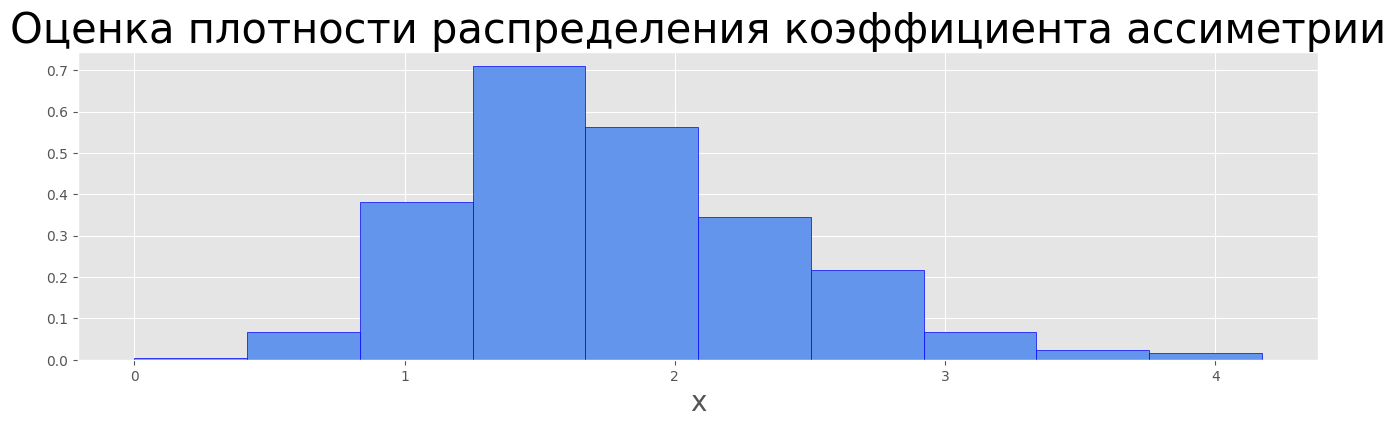

In [1635]:

def assym_coef(x):
    return Muk(x, 3)/(Muk(x,2)**1.5)

figure, axis = plt.subplots(figsize=(16, 4))


bt_assym = (stats.bootstrap((sample,), assym_coef, n_resamples=N)).bootstrap_distribution
axis.hist(bt_assym, bins=K, density=True, color="cornflowerblue", edgecolor="blue")
axis.set_xlabel("x", fontsize=20)
axis.set_title("Оценка плотности распределения коэффициента ассиметрии", fontsize=30)
plt.show()

In [1636]:
p_assym = np.sum(bt_assym[bt_assym < 1]/N) # то есть нужно посчитать сколько элементов меньше 1 и разделить на размер
print(f'Вероятность того, что коэффициент ассиметрии будет меньше 1: {p_assym}')

Вероятность того, что коэффициент ассиметрии будет меньше 1: 0.058630998931030145


# e) Сравнить плотность распределения медианы выборки с бутстраповской оценкой этой плотности


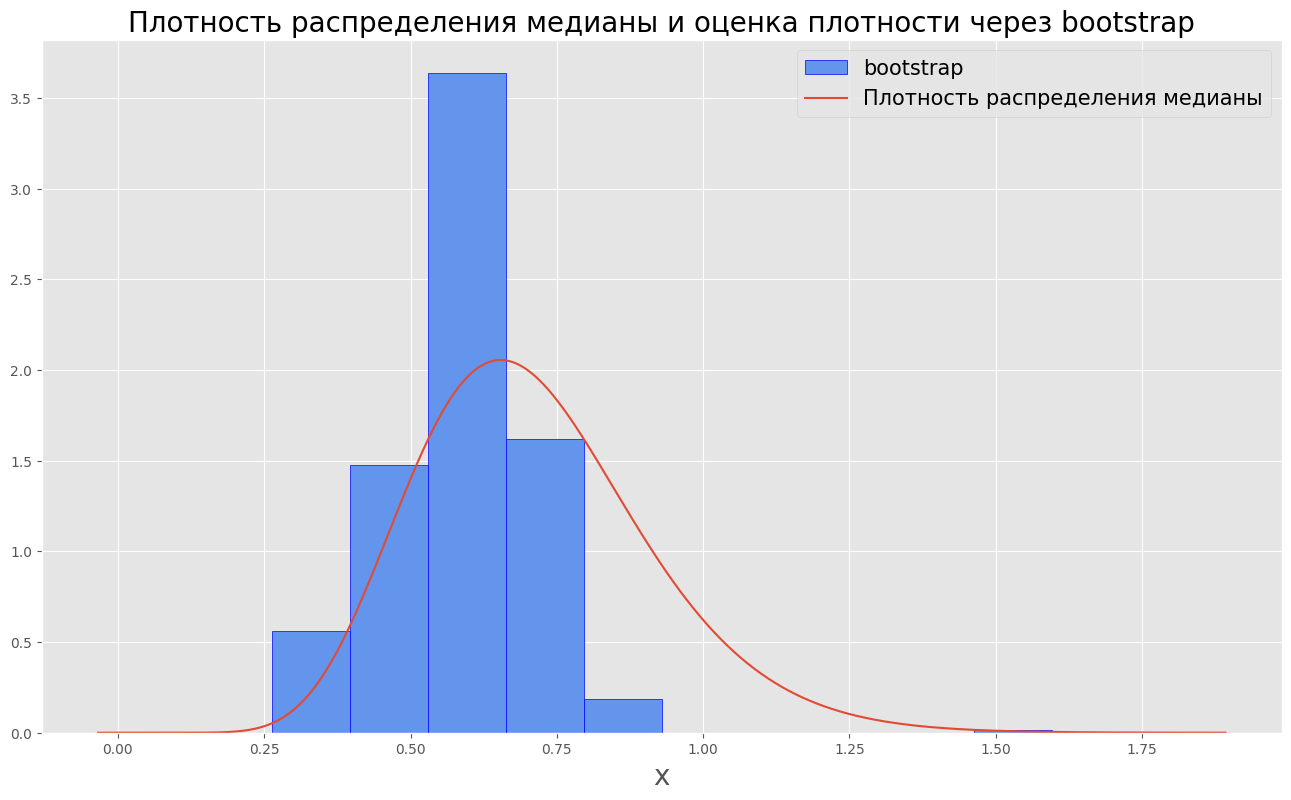

In [1637]:
bt_med = (stats.bootstrap((sample,), np.median, n_resamples=N)).bootstrap_distribution

x = np.linspace(np.min(bt_med) - np.mean(bt_mean)/4, np.max(bt_med) + np.mean(bt_mean)/4, N)
k_med = (n // 2 + (n+1)//2)*0.5 if n % 2 == 0 else n // 2 + 1
y = [distr_ordinal_stat(x[i], k_med) for i in range(len(x))]

figure, axis = plt.subplots(figsize=(16,9))
axis.hist(bt_med, bins=K, density=True, color="cornflowerblue", edgecolor="blue", label="bootstrap")
axis.plot(x, y, label="Плотность распределения медианы")
axis.set_xlabel("x", fontsize=20)
axis.set_title("Плотность распределения медианы и оценка плотности через bootstrap", fontsize=20)
axis.legend(fontsize=15)
plt.show()